In [1]:
from metric_ucfl import UCLF
import glob

In [2]:
problem_files = glob.glob('Euclid/*.txt')
# print(list(problem_files))
problem_data = {}

solution_files = glob.glob('Euclid/*.opt')
# print(list(solution_files))
solution_data = {}
solution_facilities = {}

for solution_path in solution_files:
    with open(solution_path, 'r') as f:
        for line in f:
            line_list = [int(x) for x in line.split()]
            optimal_value =  line_list[-1]
            num_facilities = len(set(line_list[:-1]))
    title = int(''.join(filter(str.isdigit, solution_path))[:-2])
    # print(f'File {title} optimal {optimal_value}')
    solution_data[title] = optimal_value
    solution_facilities[title] = num_facilities
print(solution_data)

for problem_path in problem_files:
    title = int(''.join(filter(str.isdigit, problem_path))[:-2])
    problem_data[title] = problem_path

print(problem_data)

{10: 95868, 11: 97181, 1: 96116, 12: 98528, 13: 99880, 14: 96460, 15: 99239, 16: 98486, 17: 97578, 18: 100189, 19: 98617, 20: 96938, 21: 94611, 2: 98091, 22: 98238, 23: 97419, 24: 96715, 25: 99195, 26: 96088, 27: 93845, 28: 100651, 29: 98699, 30: 98846, 3: 96212, 4: 102157, 5: 98527, 6: 98374, 7: 99331, 8: 100277, 9: 100335}
{10: 'Euclid\\1011EuclS.txt', 11: 'Euclid\\1111EuclS.txt', 1: 'Euclid\\111EuclS.txt', 12: 'Euclid\\1211EuclS.txt', 13: 'Euclid\\1311EuclS.txt', 14: 'Euclid\\1411EuclS.txt', 15: 'Euclid\\1511EuclS.txt', 16: 'Euclid\\1611EuclS.txt', 17: 'Euclid\\1711EuclS.txt', 18: 'Euclid\\1811EuclS.txt', 19: 'Euclid\\1911EuclS.txt', 20: 'Euclid\\2011EuclS.txt', 21: 'Euclid\\2111EuclS.txt', 2: 'Euclid\\211EuclS.txt', 22: 'Euclid\\2211EuclS.txt', 23: 'Euclid\\2311EuclS.txt', 24: 'Euclid\\2411EuclS.txt', 25: 'Euclid\\2511EuclS.txt', 26: 'Euclid\\2611EuclS.txt', 27: 'Euclid\\2711EuclS.txt', 28: 'Euclid\\2811EuclS.txt', 29: 'Euclid\\2911EuclS.txt', 30: 'Euclid\\3011EuclS.txt', 3: 'Eucli

We will run the 4 approximation on each problem instance and check if the relaxation solved the instance optimally 

In [4]:
# optimal, non_optimal = [], []
# for problem_number , solution in solution_data.items():
#     path = problem_data[problem_number]
#     problem_instance = UCLF(file_name=path)
#     status = problem_instance.solve_instance()
#     if status:
#         if problem_instance.primal_integral:
#             optimal.append(problem_number)
#         else:
#             non_optimal.append(problem_number)
#     else:
#         print(f'Failed to solve instance {problem_number}')

optimal = [10, 11, 1, 12, 14, 16, 17, 18, 19, 20, 21, 2, 22, 23, 24, 26, 27, 28, 29, 30, 3, 5, 6, 7, 9]

non_optimal = [13, 15, 25, 4, 8]
optimal.sort()
non_optimal.sort()

print(optimal)
print(non_optimal)

[1, 2, 3, 5, 6, 7, 9, 10, 11, 12, 14, 16, 17, 18, 19, 20, 21, 22, 23, 24, 26, 27, 28, 29, 30]
[4, 8, 13, 15, 25]


We have 5 instances in the Euclid data set that dont get solved optimally by the LP
we will solve with the 4 and and rand 3 approximations 

In [6]:
three_solutions, four_solutions, pd_solutions = {}, {}, {}

for problem_number in non_optimal:
    solution, path = solution_data[problem_number], problem_data[problem_number]
    four_instance = UCLF(file_name=path)
    four_status = four_instance.solve_instance()
    print(f'Problem: {problem_number}  Optimal: {solution} Num Cities: {solution_facilities[problem_number]}')
    if four_status:
        four_sol = four_instance.solution
        print(f'{int(four_sol.total_cost)=} {four_sol.num_facilities=} ')
        four_solutions[problem_number] = (int(four_sol.total_cost), four_sol.num_facilities )
    else:
        print(f'Failed to solve instance {problem_number}')

    three_instance = UCLF(file_name=path)
    three_status = three_instance.solve_instance(method='rand-3')
    if three_status:
        three_sol = three_instance.solution
        print(f'{int(three_sol.total_cost)=} {three_sol.num_facilities=}')
        three_solutions[problem_number] = (int(three_sol.total_cost), three_sol.num_facilities )
    else:
        print(f'Failed to solve instance {problem_number}')
    
    pd_instance = UCLF(file_name=path)
    pd_status = pd_instance.solve_instance(method='p-d-3')
    if pd_status:
        pd_sol = pd_instance.solution
        print(f'{int(pd_sol.total_cost)=} {pd_sol.num_facilities=}\n')
        pd_solutions[problem_number] = (int(pd_sol.total_cost), pd_sol.num_facilities, pd_instance.pd_iters )
    else:
        print(f'Failed to solve instance {problem_number}\n')
    


Problem: 4  Optimal: 102157 Num Cities: 15
int(four_sol.total_cost)=106705 four_sol.num_facilities=15 
int(three_sol.total_cost)=106500 three_sol.num_facilities=14
int(pd_sol.total_cost)=106750 pd_sol.num_facilities=11

Problem: 8  Optimal: 100277 Num Cities: 16
int(four_sol.total_cost)=100277 four_sol.num_facilities=16 
int(three_sol.total_cost)=100277 three_sol.num_facilities=16
int(pd_sol.total_cost)=107297 pd_sol.num_facilities=10

Problem: 13  Optimal: 99880 Num Cities: 14
int(four_sol.total_cost)=99880 four_sol.num_facilities=14 
int(three_sol.total_cost)=99880 three_sol.num_facilities=14
int(pd_sol.total_cost)=109922 pd_sol.num_facilities=10

Problem: 15  Optimal: 99239 Num Cities: 13
int(four_sol.total_cost)=99239 four_sol.num_facilities=13 
int(three_sol.total_cost)=99239 three_sol.num_facilities=13
int(pd_sol.total_cost)=102650 pd_sol.num_facilities=10

Problem: 25  Optimal: 99195 Num Cities: 16
int(four_sol.total_cost)=103519 four_sol.num_facilities=15 
int(three_sol.total_c

In [7]:
print(four_solutions)
print(three_solutions)
print(pd_solutions)

algo_performance = {
    'OPT':  [solution_data[x] for x in non_optimal],
    '4-Approximation' : [x[0] for x in four_solutions.values()],
    'Randomized 3-Approximation' : [x[0] for x in three_solutions.values()],
    '3-Approximation' : [x[0] for x in pd_solutions.values()]
}
print(algo_performance)

{4: (106705, 15), 8: (100277, 16), 13: (99880, 14), 15: (99239, 13), 25: (103519, 15)}
{4: (106500, 14), 8: (100277, 16), 13: (99880, 14), 15: (99239, 13), 25: (100653, 15)}
{4: (106750, 11, 268), 8: (107297, 10, 269), 13: (109922, 10, 289), 15: (102650, 10, 276), 25: (105045, 10, 258)}
{'OPT': [102157, 100277, 99880, 99239, 99195], '4-Approximation': [106705, 100277, 99880, 99239, 103519], 'Randomized 3-Approximation': [106500, 100277, 99880, 99239, 100653], '3-Approximation': [106750, 107297, 109922, 102650, 105045]}


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


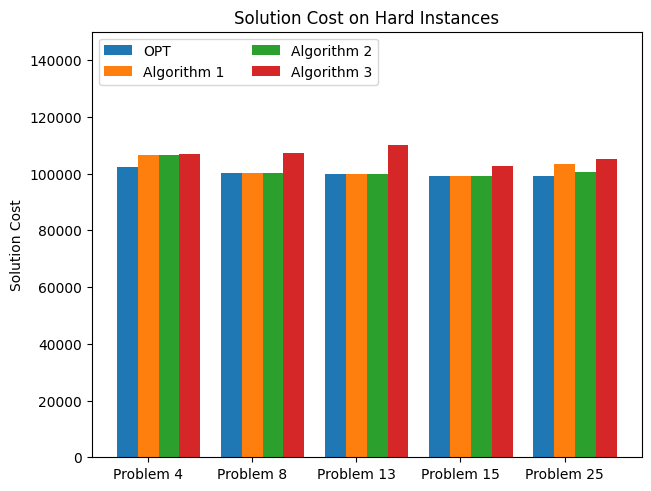

In [50]:
import matplotlib.pyplot as plt 
import numpy as np

instances = [f'Problem {x}' for x in non_optimal]
x = np.arange(len(instances)) 
width = 0.2
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

# for algo, performance in algo_performance.items():
#     offset = width * multiplier
#     print(x+offset)
#     rects = ax.bar(x + offset, performance, width, label=algo)
#     # ax.bar_label(rects, padding=3)
#     multiplier += 1

ax.bar([0., 1., 2., 3., 4.], algo_performance['OPT'], width, label='OPT')
ax.bar([0.2, 1.2, 2.2, 3.2, 4.2], algo_performance['4-Approximation'], width, label='Algorithm 1')
ax.bar([0.4, 1.4, 2.4, 3.4, 4.4], algo_performance['Randomized 3-Approximation'], width, label='Algorithm 2')
ax.bar([0.6, 1.6, 2.6, 3.6, 4.6], algo_performance['3-Approximation'], width, label='Algorithm 3')

ax.set_title('Solution Cost on Hard Instances')
ax.set_ylabel('Solution Cost')
ax.set_xticks(x + .2, instances)
# x + width
ax.legend(loc='upper left', ncols=2)
ax.set_ylim(0, 150_000)
plt.savefig('Appoximation_Performance.eps')
plt.savefig('Appoximation_Performance.png')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


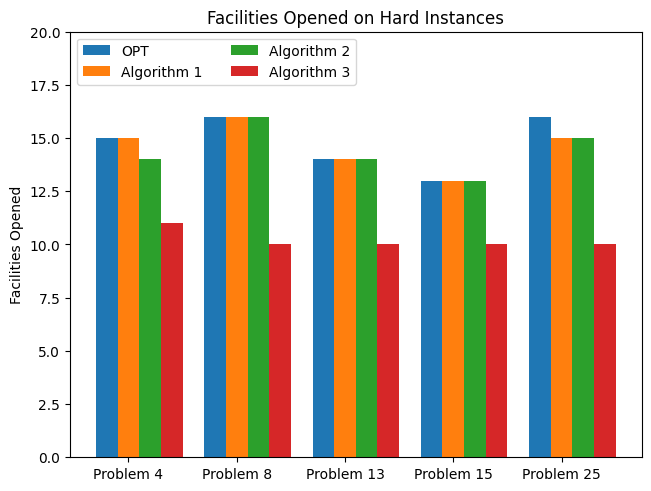

In [51]:
fig, ax = plt.subplots(layout='constrained')

ax.bar([0., 1., 2., 3., 4.], [solution_facilities[x] for x in non_optimal], width, label='OPT')
ax.bar([0.2, 1.2, 2.2, 3.2, 4.2], [x[1] for x in four_solutions.values()], width, label='Algorithm 1')
ax.bar([0.4, 1.4, 2.4, 3.4, 4.4], [x[1] for x in three_solutions.values()], width, label='Algorithm 2')
ax.bar([0.6, 1.6, 2.6, 3.6, 4.6], [x[1] for x in pd_solutions.values()], width, label='Algorithm 3')
ax.set_title('Facilities Opened on Hard Instances')
ax.set_ylabel('Facilities Opened')
ax.set_xticks(x + .2, instances)
# x + width
ax.legend(loc='upper left', ncols=2)
ax.set_ylim(0, 20)
plt.savefig('Appoximation_Facilities.eps')
plt.savefig('Appoximation_Facilities.png')
plt.show()

The primal-dual algorithm does not need to deal with the lp producing the optimal solution 
we run this algorithm on all of the instances and report its difference from the optimal

In [27]:
pd_data = {}
cost_differences = []
city_differences = []
optimal_matches = []
iter_counts = []
cost_ratios = []


for problem_number in optimal:
    solution, path = solution_data[problem_number], problem_data[problem_number]
    # print(f'Problem: {problem_number}  Optimal: {solution} Num Cities: {solution_facilities[problem_number]}')
    opt = solution
    opt_cities = solution_facilities[problem_number]

    pd_instance = UCLF(file_name=path)
    pd_status = pd_instance.solve_instance(method='p-d-3')
    if pd_status:
        pd_sol = pd_instance.solution
        print(f'{int(pd_sol.total_cost)=} {pd_sol.num_facilities=} {pd_instance.pd_iters=}')
        cost_differences.append(int(pd_sol.total_cost) - opt)
        cost_ratios.append(float( pd_sol.total_cost / opt))
        city_differences.append(pd_sol.num_facilities - opt_cities)
        optimal_matches.append(1 if int(pd_sol.total_cost) == int(opt) else 0)
        iter_counts.append(pd_instance.pd_iters)

    else:
        print(f'Failed to solve instance {problem_number}\n')

    

int(pd_sol.total_cost)=98839 pd_sol.num_facilities=10 pd_instance.pd_iters=295
int(pd_sol.total_cost)=107780 pd_sol.num_facilities=9 pd_instance.pd_iters=279
int(pd_sol.total_cost)=101328 pd_sol.num_facilities=12 pd_instance.pd_iters=282
int(pd_sol.total_cost)=103814 pd_sol.num_facilities=10 pd_instance.pd_iters=269
int(pd_sol.total_cost)=101660 pd_sol.num_facilities=12 pd_instance.pd_iters=283
int(pd_sol.total_cost)=102396 pd_sol.num_facilities=11 pd_instance.pd_iters=279
int(pd_sol.total_cost)=111842 pd_sol.num_facilities=9 pd_instance.pd_iters=274
int(pd_sol.total_cost)=99873 pd_sol.num_facilities=11 pd_instance.pd_iters=282
int(pd_sol.total_cost)=102330 pd_sol.num_facilities=12 pd_instance.pd_iters=287
int(pd_sol.total_cost)=101504 pd_sol.num_facilities=11 pd_instance.pd_iters=278
int(pd_sol.total_cost)=107044 pd_sol.num_facilities=9 pd_instance.pd_iters=276
int(pd_sol.total_cost)=101361 pd_sol.num_facilities=12 pd_instance.pd_iters=261
int(pd_sol.total_cost)=98997 pd_sol.num_facil

In [ ]:
# print(cost_differences)
# print(city_differences)
# print(sum(optimal_matches))
# print(iter_counts)
cost_ratios = np.array(cost_ratios)
city_differences = np.array(city_differences)
cost_differences = np.array(cost_differences)
iter_counts = np.array(iter_counts)

print(f'Cost Ratios - Mean: {float(cost_ratios.mean())}  std: {float(cost_ratios.std())}  min: {float(cost_ratios.min())}  max: {float(cost_ratios.max())}')

print(f'City Differences - Mean: {float(city_differences.mean())}  std: {float(city_differences.std())}  min: {float(city_differences.min())}  max: {float(city_differences.max())}')

print(f'Cost Differences - Mean: {float(cost_differences.mean())}  std: {float(cost_differences.std())}  min: {float(cost_differences.min())}  max: {float(cost_differences.max())}')

print(f'Iter Counts - Mean: {float(iter_counts.mean())}  std: {float(iter_counts.std())}  min: {float(iter_counts.min())}  max: {float(iter_counts.max())}')



Cost Ratios - Mean: 1.0487240440979226  std: 0.032568953469262925  min: 1.0099154504177803  max: 1.1418656723978966
City Differences - Mean: -2.48  std: 1.1356055653262713  min: -5.0  max: 0.0
Cost Differences - Mean: 4761.88  std: 3214.094725673156  min: 998.0  max: 14002.0
Iter Counts - Mean: 277.04  std: 11.13725280309287  min: 253.0  max: 295.0


Mean execution time

In [30]:
import time 

f_times, t_times, pd_times = [], [], []

for problem_number in non_optimal:
    solution, path = solution_data[problem_number], problem_data[problem_number]

    four_start = time.time()
    four_instance = UCLF(file_name=path)
    four_status = four_instance.solve_instance()
    four_end = time.time()

    three_start = time.time()
    three_instance = UCLF(file_name=path)
    three_status = three_instance.solve_instance(method='rand-3')
    three_end = time.time()

    pd_start = time.time()
    pd_instance = UCLF(file_name=path)
    pd_status = pd_instance.solve_instance(method='p-d-3')
    pd_end = time.time()

    four_time, three_time, pd_time = four_end-four_start, three_end-three_start, pd_end-pd_start
    print(f'Instace {problem_number} 4: {four_time} 3: {three_time} pd:{pd_time}')
    f_times.append(four_time)
    t_times.append(three_time)
    pd_times.append(pd_time)

    


Instace 4 4: 0.8068752288818359 3: 0.8561432361602783 pd:3.124189853668213
Instace 8 4: 0.8020036220550537 3: 0.794959306716919 pd:3.145928382873535
Instace 13 4: 0.8209633827209473 3: 0.7655580043792725 pd:3.256277561187744
Instace 15 4: 0.8616526126861572 3: 0.8099415302276611 pd:3.2201647758483887
Instace 25 4: 0.81292724609375 3: 0.8252987861633301 pd:3.0816597938537598


In [31]:
print(f'Four Approx mean time: {float(np.mean(f_times))}')
print(f'Three Approx mean time: {float(np.mean(t_times))}')
print(f'Primal-Dual Approx mean time: {float(np.mean(pd_times))}')

Four Approx mean time: 0.8208844184875488
Three Approx mean time: 0.8103801727294921
Primal-Dual Approx mean time: 3.165644073486328


randomized performance across the hard instances

In [ ]:
trials = 50
[4, 8, 13, 15, 25]
p4, p8, p13, p15, p25 = [], [], [], [], []
for _ in range(trials):
    p4_instance =  UCLF(file_name='Euclid/411EuclS.txt')
    p8_instance =  UCLF(file_name='Euclid/811EuclS.txt')
    p13_instance =  UCLF(file_name='Euclid/1311EuclS.txt')
    p15_instance =  UCLF(file_name='Euclid/1511EuclS.txt')
    p25_instance =  UCLF(file_name='Euclid/2511EuclS.txt')
    
    p4_instance.solve_instance(method='rand-3')
    p8_instance.solve_instance(method='rand-3')
    p13_instance.solve_instance(method='rand-3')
    p15_instance.solve_instance(method='rand-3')
    p25_instance.solve_instance(method='rand-3')

    p4.append(p4_instance.solution.total_cost)
    p8.append(p8_instance.solution.total_cost)
    p13.append(p13_instance.solution.total_cost)
    p15.append(p15_instance.solution.total_cost)
    p25.append(p25_instance.solution.total_cost)


[np.int64(109625), np.int64(108253), np.int64(107239), np.int64(108253), np.int64(106189), np.int64(103452), np.int64(106500), np.int64(104466), np.int64(105752), np.int64(109625), np.int64(107068), np.int64(105923), np.int64(107987), np.int64(107068), np.int64(107239), np.int64(103452), np.int64(109359), np.int64(106888), np.int64(107987), np.int64(108253), np.int64(103452), np.int64(105565), np.int64(109625), np.int64(106888), np.int64(104466), np.int64(106937), np.int64(104466), np.int64(106937), np.int64(105299), np.int64(105128), np.int64(104029), np.int64(105128), np.int64(104380), np.int64(104817), np.int64(103718), np.int64(107816), np.int64(107154), np.int64(106140), np.int64(106937), np.int64(109359), np.int64(104466), np.int64(105565), np.int64(104029), np.int64(104029), np.int64(103452), np.int64(105128), np.int64(106937), np.int64(108253), np.int64(106189), np.int64(105128)]


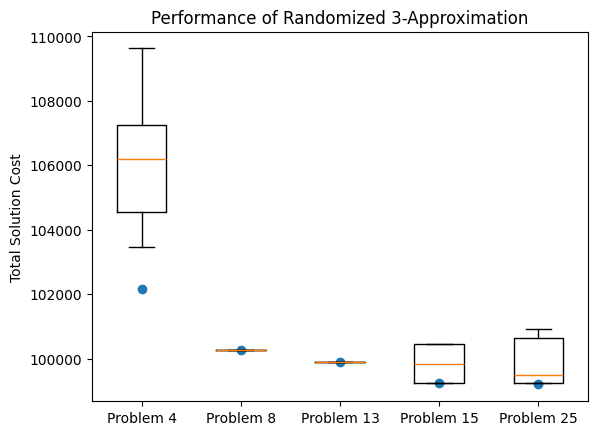

In [49]:
data = [np.array(p4), np.array(p8), np.array(p13), np.array(p15), np.array(p25)]
labels = [f'Problem {x}' for x in non_optimal]

fig, ax = plt.subplots()
ax.set_ylabel('Total Solution Cost')
ax.set_title('Performance of Randomized 3-Approximation')
box = ax.boxplot(data, tick_labels=labels, autorange=True)
plt.scatter(list(range(1,6)), [solution_data[x] for x in non_optimal])
plt.savefig('three-performance.eps')
plt.savefig('three-performance.png')
plt.show()
